In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("results/first.csv")
df2 = pd.read_csv("results/second.csv")
df3 = pd.read_csv("results/third.csv")

In [3]:
combined_df = pd.concat([df1, df2, df3], ignore_index=True)
filtered_df = combined_df[~combined_df["Status"].isin(["RETURNED", "TIMED-OUT"])]

In [4]:
# Count the number of males and females
sex_counts = filtered_df["Sex"].value_counts()

# Display the counts
print("Gender Distribution:")
print(sex_counts)

Gender Distribution:
Sex
Male      57
Female    43
Name: count, dtype: int64


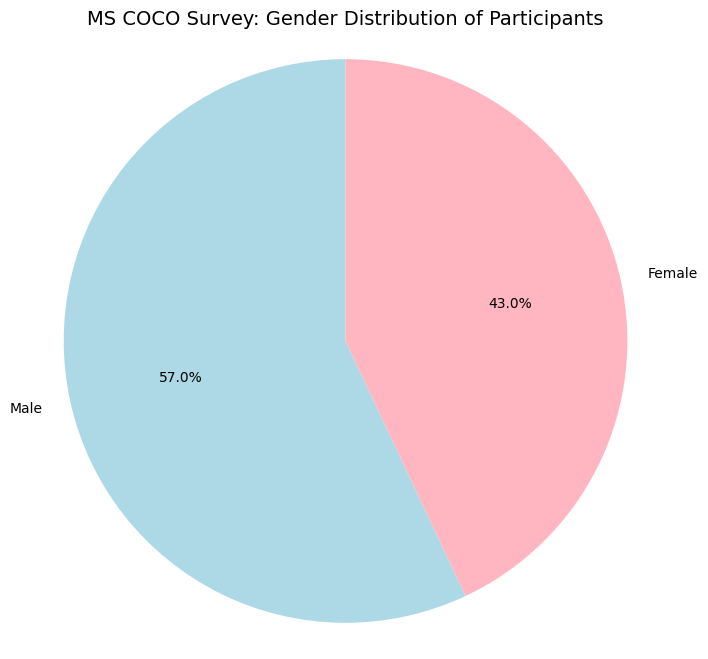

In [5]:
plt.figure(figsize=(8, 8))
plt.pie(sex_counts, labels=sex_counts.index, autopct="%1.1f%%", 
        colors=["lightblue", "lightpink"], startangle=90)
plt.title("MS COCO Survey: Gender Distribution of Participants", fontsize=14)
plt.axis("equal")
plt.savefig("results/mscoco_gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
df_clean = filtered_df.copy()
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")
average_age = df_clean["Age"].mean()
print(f"Average Age: {average_age:.1f} years")
min_age = df_clean["Age"].min()
max_age = df_clean["Age"].max()
print(f"Age Range: {min_age:.0f} to {max_age:.0f} years")

Average Age: 33.5 years
Age Range: 19 to 65 years


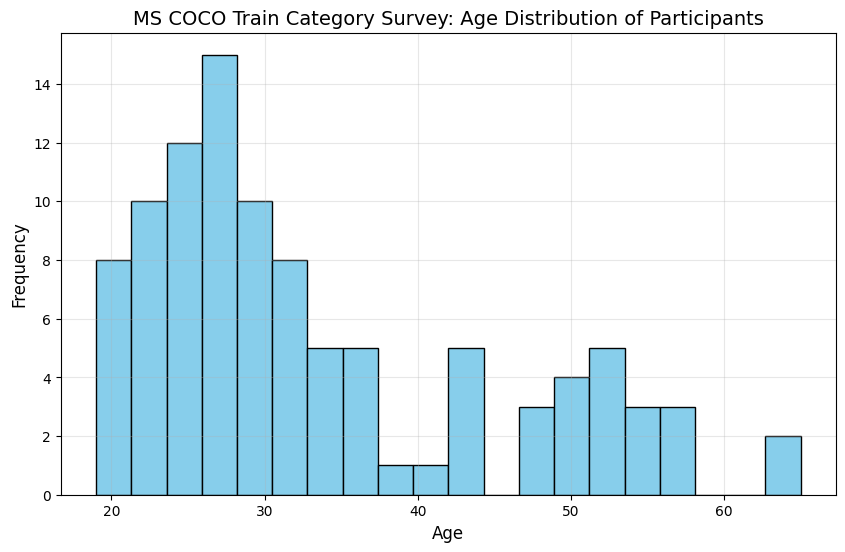

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Age"], bins=20, edgecolor="black", color="skyblue")
plt.title("MS COCO Train Category Survey: Age Distribution of Participants", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig("results/mscoco_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

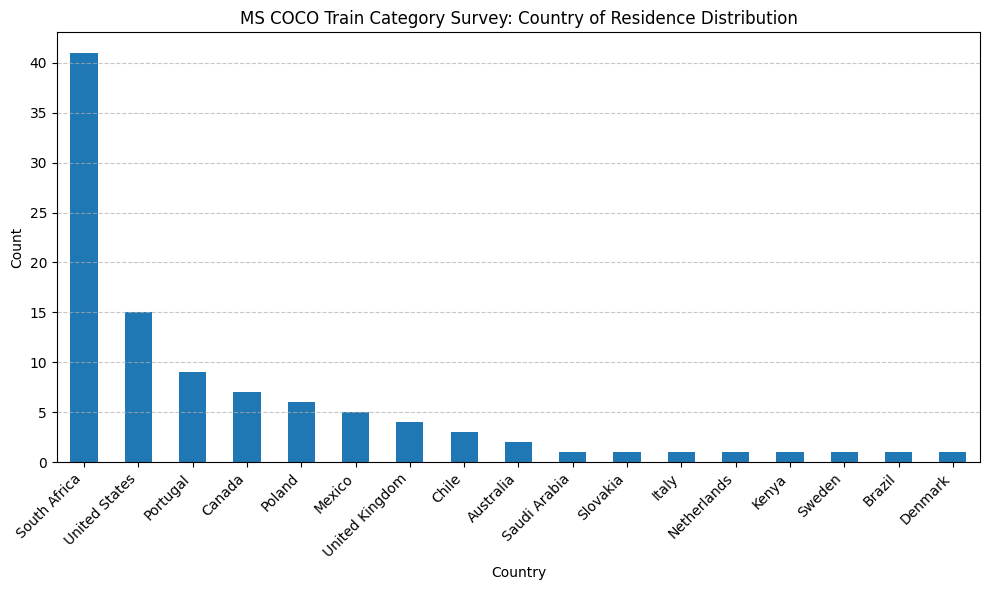

In [10]:
country_counts = df_clean["Country of residence"].value_counts()

# Plot
plt.figure(figsize=(10, 6))
country_counts.plot(kind="bar")

plt.title("MS COCO Train Category Survey: Country of Residence Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("results/mscoco_country_distribution.png", dpi=300, bbox_inches="tight")
plt.show()